# Network Traffic with Game Theory

> Computational Analysis of Social Complexity
>
> Fall 2025, Spencer Lyon

**Prerequisites**

- Networks
- Game Theory

**Outcomes**

- Represent network traffic weighted DiGraph
- Analyze equilibrium network outcomes using the concept of Nash Equilibirum
- Understand Braes' paradox
- Learn about the concept of social welfare and a social planners


**References**

- [Easley and Kleinberg](https://www.cs.cornell.edu/home/kleinber/networks-book/) chapter 8


## Congestion

- We regularly use physical networks of all kinds
  - Power grids
  - The internet
  - Streets
  - Railroads
- What happens when the networks get congested?
  - Typically -- flow across the network slows down
- Today we'll study how game theoretic ideas are helpful when analyzing how a network with finite capacity or increasing costs


## A Traffic Network

- We'll start by considering a traffic network
- The figure caption has extra detail -- so be sure to read it!
![https://compsosci-resources.s3.amazonaws.com/game_theory_lectures/traffic_graph.png](https://compsosci-resources.s3.amazonaws.com/game_theory_lectures/traffic_graph.png)

- We'll write up some helper Python functions that will let us create and visualize the traffic network for arbitrary values of x


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
def traffic_graph1(x):
    G = nx.DiGraph()
    G.add_nodes_from(["A", "B", "C", "D"])
    G.add_edge("A", "C", weight=x / 100)
    G.add_edge("A", "D", weight=45)
    G.add_edge("C", "B", weight=45)
    G.add_edge("D", "B", weight=x / 100)
    return G

In [3]:
def plot_traffic_graph(G):
    pos = {"A": (1.0, 1), "B": (3, 1), "C": (2, 0), "D": (2, 2)}
    fig, ax = plt.subplots(figsize=(6, 6))
    nx.draw(
        G, pos, ax=ax, with_labels=True, node_color="lightblue",
        node_size=1200, font_weight="bold", arrowsize=20,
    )
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax)
    plt.show()

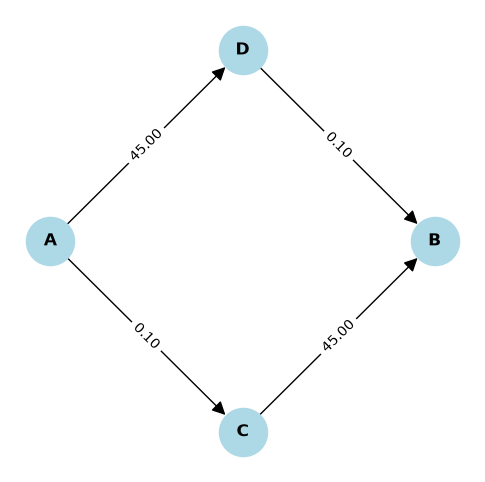

In [4]:
plot_traffic_graph(traffic_graph1(10))

- Try changing the argument to `traffic_graph1` to see how the network changes


### The Game

- Now suppose, as indicated in the figure caption, that we have 4,000 drivers that need to commute from A to B in the morning
- If all take the upper route (A-C-B) we get a total time of 40 + 45 = 85 minutes
- If all take the lower route (A-D-B) we get a total time of 40 + 45 = 85 minutes
- If, however, they evenly divide we get a total time of 20 + 45 = 65 minutes


### Equilibrium

- Recall that for a set of strategies (here driving paths) to be a Nash Equilibrium, each player's strategy must be a best response to the strategy of all other players
- We'll argue that the only NE of this commuting game is that 2,000 drivers take (A-C-B) and 2,000 take (A-D-B) and everyone takes 65 minutes to commute

### Exercise

- Show that this strategy (2,000 drivers take (A-C-B) and 2,000 take (A-D-B)) is indeed a Nash equilibrium
- To do this recognize that the game is symmetric for all drivers
- Then, argue that if 3,999 drivers are following that strategy, the best response for the last driver is also to follow the strategy 


### Numerical Verification

Let's verify why the 50-50 split is indeed an equilibrium:

**Current equilibrium**: 2,000 drivers on each path, everyone takes 65 minutes

**If you're driver #2,001 considering which path to take:**
- If you join the upper path (A-C-B): 
  - Edge A-C now has 2,001 drivers: 2,001/100 = 20.01 minutes
  - Edge C-B still takes 45 minutes
  - Total time: 20.01 + 45 = 65.01 minutes
  
- If you join the lower path (A-D-B):
  - Edge A-D now has 2,001 drivers: 2,001/100 = 20.01 minutes  
  - Edge D-B still takes 45 minutes
  - Total time: 20.01 + 45 = 65.01 minutes

**Result**: Both paths give the same travel time! No driver has an incentive to switch paths. This confirms our Nash equilibrium.

- Your work HERE!


### Discussion

- Note a powerful outcome here -- without any coordination by a central authority, drivers  will automatically balance perfectly in equilibrium
- The only assumptions we made were:
  1. Drivers want to minimize driving time
  2. Drivers are allowed to respond to the decisions of others
- The first assumption is very plausable -- nobody wants to sit in more traffic than necessary
- The second highlights a key facet of our modern society...
  - Information availability (here decisions of other drivers) can (and does!) lead to optimal outcomes without the need for further regulation or policing


```python
def traffic_graph2(x):
    G = traffic_graph1(x)
    # Add an edge with minimal weight (1e-16 instead of 0) because
    # nx.draw doesn't display edges with weight 0 as clearly
    G.add_edge("C", "D", weight=1e-16)
    return G
```

In [5]:
def traffic_graph2(x):
    G = traffic_graph1(x)
    # need to add an edge with minimal weight so it shows up in plot
    G.add_edge("C", "D", weight=1e-16)
    return G

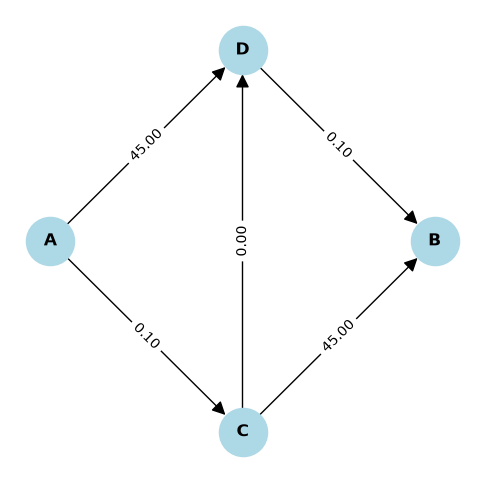

In [6]:
plot_traffic_graph(traffic_graph2(10))

### Exercise

- Is a 50/50 split of traffic still a Nash equilibrium in this case?
- Why or why not?
- Is all 4,000 drivers doing (A-C-D-B) a Nash equilibrium?
- Why or why not?


### Braess' Paradox

- In the previous exercise, we saw a rather startling result...
- Doing a network "upgrade" -- adding a wormhole connecting C and D -- resulted in a *worse* equilibrium outcome for everyone!
- The equilibrium driving time is now 80 minutes for all drivers instead of 65 minutes (which was the case before the wormhole)
- This is known as Braess' paradox

### Real-World Examples

Braess' paradox is not just theoretical - it has been observed in real traffic networks:

- **New York City (1990)**: When 42nd Street was closed for Earth Day, traffic flow actually *improved* rather than worsened. The city later made some closures permanent.

- **Stuttgart, Germany (1969)**: After investing in a new road to ease congestion, traffic conditions worsened. The road was eventually removed, restoring better traffic flow.

- **Seoul, South Korea (2003)**: The demolition of the Cheonggyecheon highway led to improved traffic conditions, contrary to predictions of chaos.

These cases demonstrate that sometimes *removing* network capacity can lead to better equilibrium outcomes - a counterintuitive result that game theory helps us understand!

### Follow ups

- Braess' paradox was the starting point for a large body of research on using game theory to analyze network traffic
- Some questions that have been asked are:
  - How much larger can equilibrium travel time increase after a network upgrade?
  - How can network upgrade be designed to be resilient to Braess' paradox?

## Social Welfare

- Many economic models are composed of individual actors who make autonomous decisions and have autonomous payoffs
- We've been studying some of these settings using tools from game theory, focusing on the *individual* perspective
  - Our notion of equilibrium is dependent on no individual wanting to change strategy in response to other strategies
- Another form of analysis works at the macro level -- we analyze the **total** payoff for all agents (i.e. sum of payoffs)
- We call this aggregate payoff **social welfare**


### The Social Planner

- In an economic model, someone who seeks to maximize social welfare is called a *social planner*
- A social planner is given the authority to make decisions for all agents
- In our traffic model, a social planner would choose to ignore the wormhole and have 1/2 the drivers take A-C-B and the other half take A-D-B
  - In this case everyone would be better off with a cost of 65 minutes instead of the equilibrium 80 minutes


### Cost of Freedom

- Question: in a generic traffic model, how much *worse* can the equilibrium outcome be than the social optimum?
- In our example, 
  - Optimal social welfare is 4000 * 65 = 260,000 total minutes
  - Equilibrium social welfare is 4000 * 80 = 320,000 total minutes  
  - A change of 60,000 total minutes
- **Price of Anarchy**: This ratio of equilibrium cost to optimal cost is formally called the *Price of Anarchy*
  - Price of Anarchy = Worst Nash Equilibrium Cost / Social Optimum Cost
  - In our example: PoA = 320,000 / 260,000 = 1.23 (the equilibrium is 23% worse than optimal)
- To answer this question for a general traffic model, we need to be able to compute the equilibrium for a generic traffic model
- We may study this next week, or perhaps even on your homework 😉